In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

print("Data loaded!", fraud_df.shape)

Data loaded! (151112, 11)


In [2]:
# Time since signup in hours
fraud_df['time_since_signup'] = (
    fraud_df['purchase_time'] - fraud_df['signup_time']
).dt.total_seconds() / 3600

# Hour of day and day of week
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek

print("Time features created!")
print(fraud_df[['time_since_signup', 'hour_of_day', 'day_of_week']].describe())

Time features created!
       time_since_signup    hour_of_day    day_of_week
count      151112.000000  151112.000000  151112.000000
mean         1370.008125      11.521593       3.011819
std           868.406422       6.912474       2.006203
min             0.000278       0.000000       0.000000
25%           607.431528       6.000000       1.000000
50%          1368.429306      12.000000       3.000000
75%          2123.479028      17.000000       5.000000
max          2879.992222      23.000000       6.000000


In [3]:
# Number of transactions per user
fraud_df['user_txn_count'] = fraud_df.groupby('user_id')['user_id'].transform('count')

# Number of transactions per device
fraud_df['device_txn_count'] = fraud_df.groupby('device_id')['device_id'].transform('count')

print("Velocity features created!")
print(fraud_df[['user_txn_count', 'device_txn_count']].describe())

Velocity features created!
       user_txn_count  device_txn_count
count        151112.0     151112.000000
mean              1.0          1.684367
std               0.0          2.616954
min               1.0          1.000000
25%               1.0          1.000000
50%               1.0          1.000000
75%               1.0          1.000000
max               1.0         20.000000


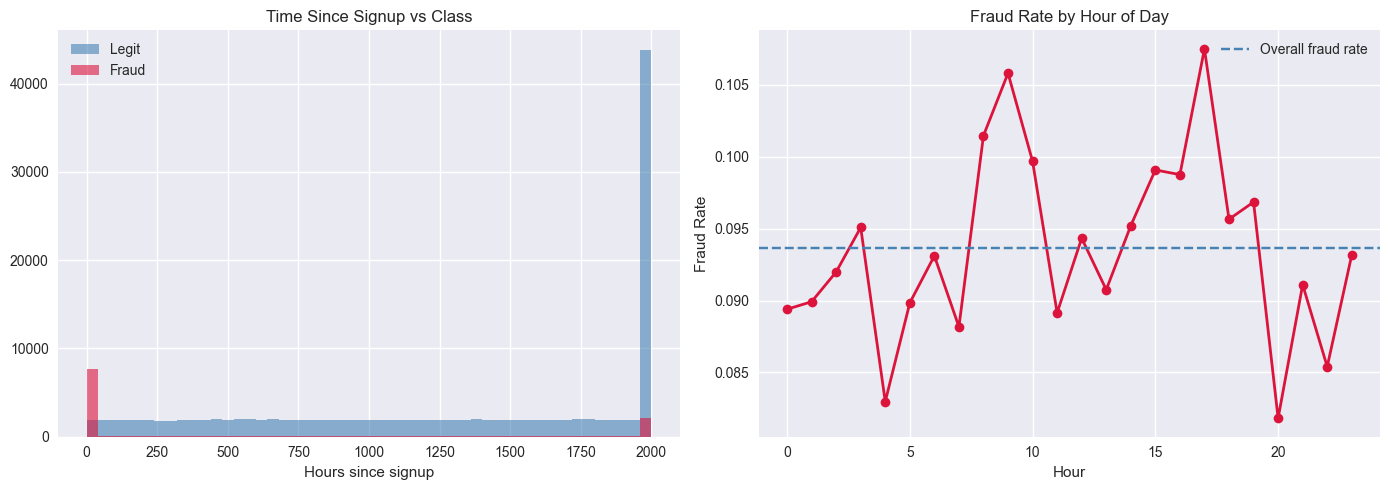

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# time_since_signup distribution by class
axes[0].hist(fraud_df[fraud_df['class']==0]['time_since_signup'].clip(0, 2000), 
             bins=50, alpha=0.6, color='steelblue', label='Legit')
axes[0].hist(fraud_df[fraud_df['class']==1]['time_since_signup'].clip(0, 2000), 
             bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[0].set_title('Time Since Signup vs Class')
axes[0].set_xlabel('Hours since signup')
axes[0].legend()

# hour_of_day fraud rate
fraud_by_hour = fraud_df.groupby('hour_of_day')['class'].mean()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values, 
             color='crimson', marker='o', linewidth=2)
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')
axes[1].axhline(fraud_df['class'].mean(), color='steelblue', 
                linestyle='--', label='Overall fraud rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/feature_engineering_viz.png')
plt.show()

In [5]:
# Convert IP to integer
fraud_df['ip_int'] = fraud_df['ip_address'].astype(np.int64)
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(np.int64)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(np.int64)

# Sort for merge_asof
fraud_sorted = fraud_df.sort_values('ip_int').reset_index(drop=True)
ip_sorted = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)

# Range-based merge
merged = pd.merge_asof(
    fraud_sorted,
    ip_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Validate match
merged['country'] = merged.apply(
    lambda r: r['country'] if r['ip_int'] <= r['upper_bound_ip_address'] else 'Unknown',
    axis=1
)

print("Country mapping complete!")
print(merged['country'].value_counts().head(10))

Country mapping complete!
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


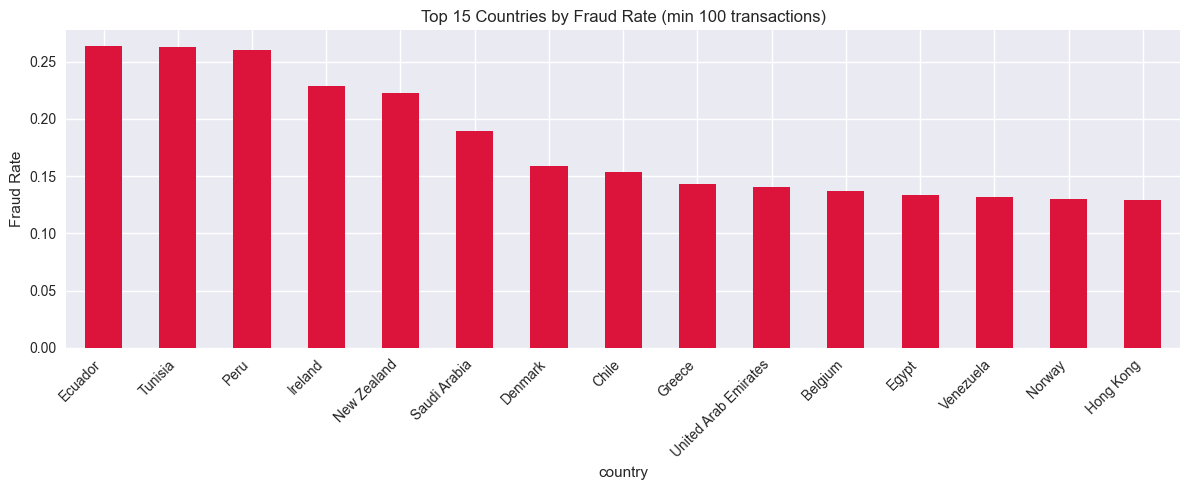

In [6]:
fraud_by_country = merged.groupby('country')['class'].agg(['mean','count'])
fraud_by_country.columns = ['fraud_rate', 'total_txns']
fraud_by_country = fraud_by_country[fraud_by_country['total_txns'] > 100]
top_fraud_countries = fraud_by_country.sort_values('fraud_rate', ascending=False).head(15)

plt.figure(figsize=(12, 5))
top_fraud_countries['fraud_rate'].plot(kind='bar', color='crimson')
plt.title('Top 15 Countries by Fraud Rate (min 100 transactions)')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/fraud_by_country_fe.png')
plt.show()

In [7]:
# Save the enriched dataset
cols_to_save = ['user_id', 'purchase_value', 'age', 'class',
                'time_since_signup', 'hour_of_day', 'day_of_week',
                'user_txn_count', 'device_txn_count', 'country',
                'source', 'browser', 'sex']

merged[cols_to_save].to_csv('../data/processed/fraud_engineered.csv', index=False)
print("Feature engineered dataset saved!")
print("Shape:", merged[cols_to_save].shape)

Feature engineered dataset saved!
Shape: (151112, 13)
